# Project Milestone Two: Modeling and Feature Engineering

### Due: Midnight on April 13 (with 2-hour grace period) and worth 25 points

### Overview

This milestone builds on your work from Milestone 1. You will:

1. Evaluate baseline models using default settings.
2. Engineer new features and re-evaluate models.
3. Use feature selection techniques to find promising subsets.
4. Select the top 3 models and fine-tune them for optimal performance.

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone.


In [6]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling.

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:**

- You will not use the testing set during this milestone — it’s reserved for final evaluation later.
- You will have to redo the scaling step when you introduce new features (which have to be scaled as well).


In [7]:
# Add as many code cells as you need
df = pd.read_csv("/content/zillow_cleaned.csv")

In [103]:
df.head()

,parcelid,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fireplacecnt,...,regionidneighborhood,regionidzip,roomcnt,threequarterbathnbr,unitcnt,yearbuilt,numberofstories,assessmentyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,3.5,4.0,NaN,3.5,3100.0,3100.0,6059.0,NaN,...,NaN,96978.0,0.0,1.0,NaN,1998.0,NaN,2016.0,6.059063e+13,1023282.0
1,17052889,NaN,1.0,2.0,NaN,1.0,1465.0,1465.0,6111.0,1.0,...,NaN,97099.0,5.0,NaN,NaN,1967.0,1.0,2016.0,6.111001e+13,464000.0
2,14186244,NaN,2.0,3.0,NaN,2.0,1243.0,1243.0,6059.0,NaN,...,NaN,97078.0,6.0,NaN,NaN,1962.0,1.0,2016.0,6.059022e+13,564778.0
3,12177905,NaN,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,NaN,...,NaN,96330.0,0.0,NaN,1.0,1970.0,NaN,2016.0,6.037300e+13,145143.0
4,10887214,1.0,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,NaN,...,268548.0,96451.0,0.0,NaN,1.0,1964.0,NaN,2016.0,6.037124e+13,119407.0


In [104]:
# Split the dataset into features X and y
X = df.drop(columns=['taxvaluedollarcnt'])   # All columns except the one we're trying to predict
y = df['taxvaluedollarcnt']                  # The target column = what we want to predict

# Split the data into training and test sets (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Drop non-numeric columns
X_train = X_train.drop(columns=['propertycountylandusecode', 'propertyzoningdesc'])

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)  # This returns a NumPy array

# Scale the imputed values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Check if any missing value remain
print("Missing values after imputation and scaling:", np.isnan(X_train_scaled).sum())

Missing values after imputation and scaling: 0


### Part 1: Baseline Modeling [3 pts]

Apply the following regression models to the scaled training dataset using **default parameters**:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each model:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV RMSE Score** across all folds in a table.


In [8]:
from sklearn.metrics import make_scorer

# Define custom RMSE scorer
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse)
#

In [9]:
# 5-fold cross-validation repeated 5 times
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)


In [71]:
# Linear Regression

model = LinearRegression()

# Cross-validation scores
rmse_scores = cross_val_score(model, X_train_scaled, y_train,
                                  scoring=rmse_scorer, cv=cv)

# mean and standard deviation
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print("Linear Regression:")
print(f"Mean RMSE: {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")


Linear Regression:
Mean RMSE: 194969.97
Standard Deviation of RMSE: 926.16


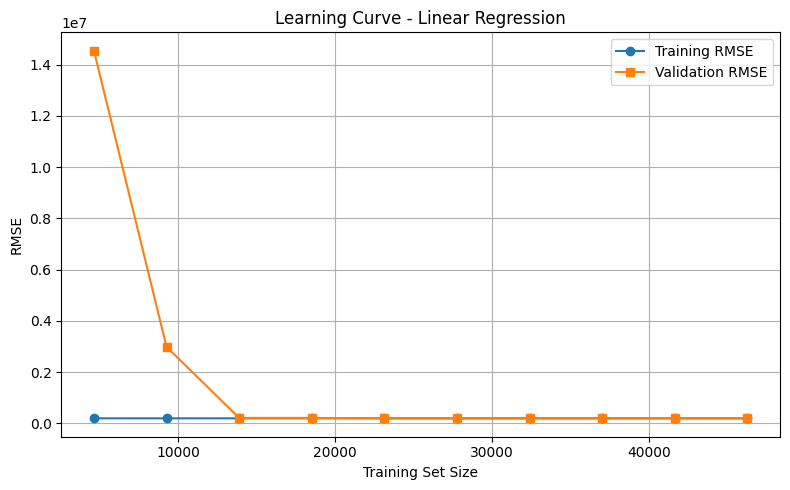

In [72]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',  # or your RMSE scorer
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Convert to positive RMSE
train_rmse = -np.mean(train_scores, axis=1)
val_rmse = -np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, label='Training RMSE', marker='o')
plt.plot(train_sizes, val_rmse, label='Validation RMSE', marker='s')
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Learning Curve - Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [73]:
# Ridge Regression

model = Ridge()

# Cross-validation scores
rmse_scores = cross_val_score(model, X_train_scaled, y_train,
                                  scoring=rmse_scorer, cv=cv)

# mean and standard deviation
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print("Ridge Regression:")
print(f"Mean RMSE: {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")


Ridge Regression:
Mean RMSE: 195053.53
Standard Deviation of RMSE: 919.06


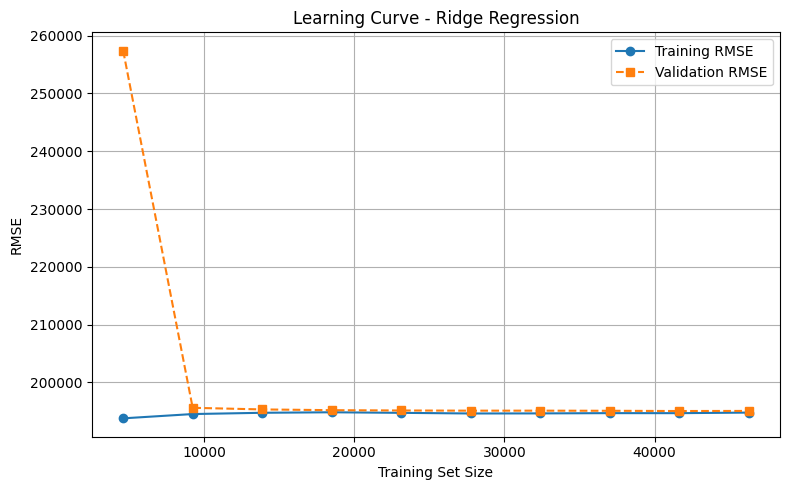

In [74]:


# Ridge model
model = Ridge()

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error',
    shuffle=True,
    random_state=42
)

# Convert negative RMSE to positive
train_rmse = -np.mean(train_scores, axis=1)
val_rmse = -np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', label='Training RMSE')
plt.plot(train_sizes, val_rmse, 's--', label='Validation RMSE')
plt.title("Learning Curve - Ridge Regression")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [75]:
# Lasso Regression

model = Lasso(alpha=1.0, max_iter=10000)

# Cross-validation scores
rmse_scores = cross_val_score(model, X_train_scaled, y_train,
                                  scoring=rmse_scorer, cv=cv)

# mean and standard deviation
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print("Lasso Regression:")
print(f"Mean RMSE: {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.517e+14, tolerance: 2.591e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.492e+14, tolerance: 2.598e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.538e+14, tolerance: 2.600e

Lasso Regression:
Mean RMSE: 195109.79
Standard Deviation of RMSE: 913.56


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.517e+14, tolerance: 2.596e+11
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.346e+13, tolerance: 2.549e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.674e+14, tolerance: 5.186e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.548e+14, tolerance: 7.825e

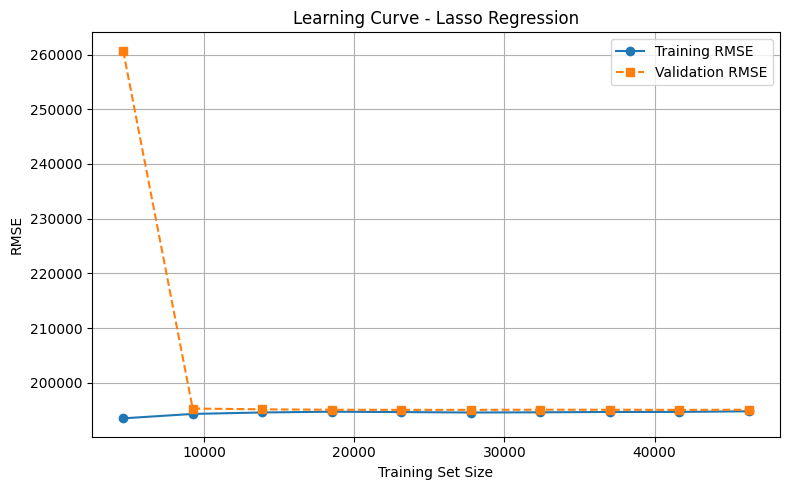

In [76]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error',
    shuffle=True,
    random_state=42
)

# Convert negative RMSE to positive
train_rmse = -np.mean(train_scores, axis=1)
val_rmse = -np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', label='Training RMSE')
plt.plot(train_sizes, val_rmse, 's--', label='Validation RMSE')
plt.title("Learning Curve - Lasso Regression")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [77]:
# Decision Tree Regression

from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()

# Cross-validation scores
rmse_scores = cross_val_score(model, X_train_scaled, y_train,
                                  scoring=rmse_scorer, cv=cv)

# mean and standard deviation
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print("Decision Tree Regression:")
print(f"Mean RMSE: {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")


Decision Tree Regression:
Mean RMSE: 246055.00
Standard Deviation of RMSE: 1917.22


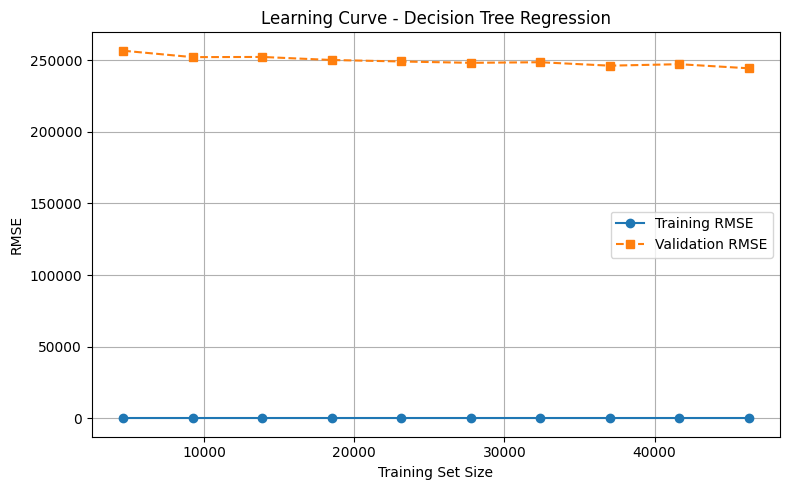

In [78]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error',
    shuffle=True,
    random_state=42
)

# Convert negative RMSE to positive
train_rmse = -np.mean(train_scores, axis=1)
val_rmse = -np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', label='Training RMSE')
plt.plot(train_sizes, val_rmse, 's--', label='Validation RMSE')
plt.title("Learning Curve - Decision Tree Regression")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [79]:
#Bagging
model = BaggingRegressor()

# Cross-validation scores
rmse_scores = cross_val_score(model, X_train_scaled, y_train,
                                  scoring=rmse_scorer, cv=cv)

# mean and standard deviation
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print("Bagging:")
print(f"Mean RMSE: {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")

Bagging:
Mean RMSE: 186933.67
Standard Deviation of RMSE: 1069.20


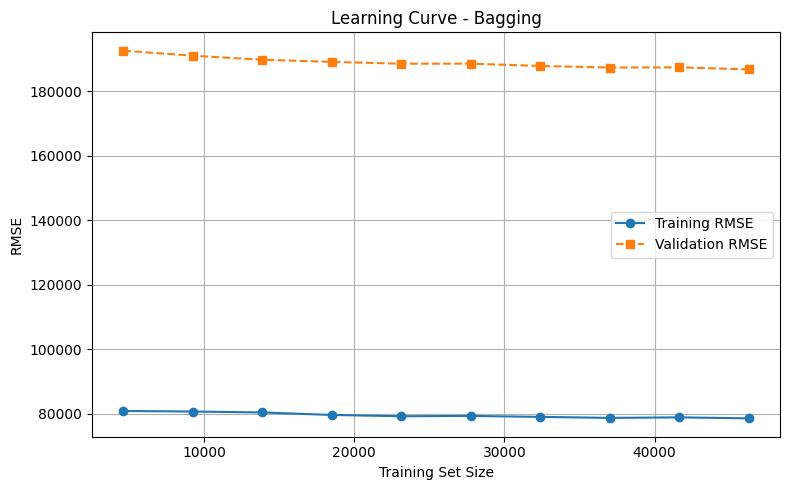

In [80]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error',
    shuffle=True,
    random_state=42
)

# Convert negative RMSE to positive
train_rmse = -np.mean(train_scores, axis=1)
val_rmse = -np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', label='Training RMSE')
plt.plot(train_sizes, val_rmse, 's--', label='Validation RMSE')
plt.title("Learning Curve - Bagging")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [81]:
#Random Forest Regression
model = RandomForestRegressor()

# Cross-validation scores
rmse_scores = cross_val_score(model, X_train_scaled, y_train,
                                  scoring=rmse_scorer, cv=cv)

# mean and standard deviation
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print("Random Forest Regression:")
print(f"Mean RMSE: {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")

Random Forest Regression:
Mean RMSE: 179905.52
Standard Deviation of RMSE: 965.26


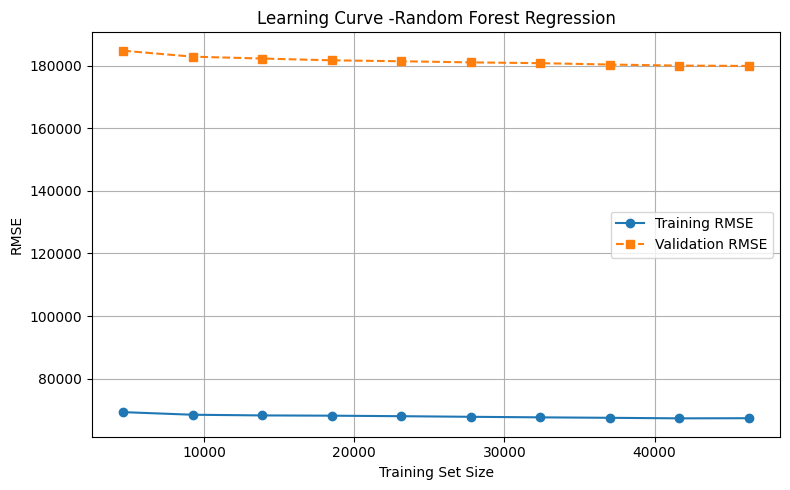

In [82]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error',
    shuffle=True,
    random_state=42
)

# Convert negative RMSE to positive
train_rmse = -np.mean(train_scores, axis=1)
val_rmse = -np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', label='Training RMSE')
plt.plot(train_sizes, val_rmse, 's--', label='Validation RMSE')
plt.title("Learning Curve -Random Forest Regression")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [83]:
#Gradient Boosting Trees
model = GradientBoostingRegressor()

# Cross-validation scores
rmse_scores = cross_val_score(model, X_train_scaled, y_train,
                                  scoring=rmse_scorer, cv=cv)
# mean and standard deviation
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print("Gradient Boosting Trees:")
print(f"Mean RMSE: {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")


Gradient Boosting Trees:
Mean RMSE: 179707.00
Standard Deviation of RMSE: 853.71


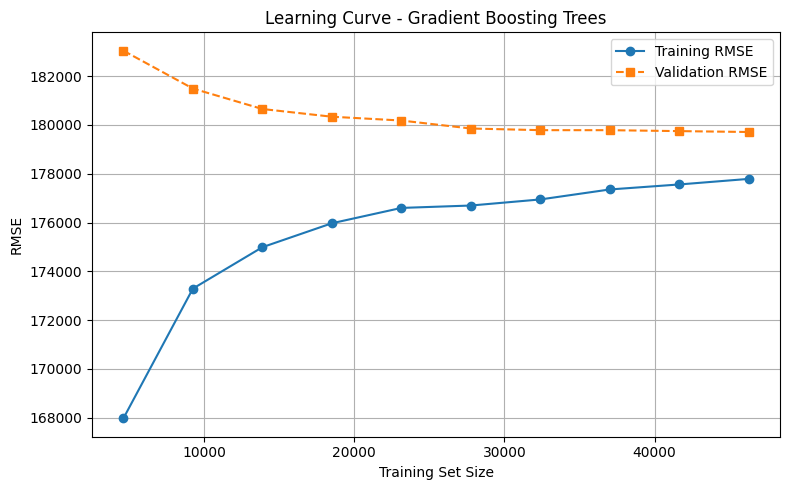

In [84]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error',
    shuffle=True,
    random_state=42
)

# Convert negative RMSE to positive
train_rmse = -np.mean(train_scores, axis=1)
val_rmse = -np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', label='Training RMSE')
plt.plot(train_sizes, val_rmse, 's--', label='Validation RMSE')
plt.title("Learning Curve - Gradient Boosting Trees")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [108]:
 #part 1:
results = [
    {"Model": "Linear Regression", "Mean RMSE": 194966.11, "Std RMSE": 908.18},
    {"Model": "Ridge Regression", "Mean RMSE": 195049.19, "Std RMSE": 901.13},
    {"Model": "Lasso Regression", "Mean RMSE": 195105.69, "Std RMSE": 895.92},
    {"Model": "Decision Tree Regression", "Mean RMSE": 245975.56, "Std RMSE": 1720.64},
    {"Model": "Bagging", "Mean RMSE": 187060.06, "Std RMSE": 1223.41},
    {"Model": "Random Forest Regression", "Mean RMSE": 179880.39, "Std RMSE": 979.02},
    {"Model": "Gradient Boosting Trees", "Mean RMSE": 179693.40, "Std RMSE": 877.85}
]
results_df = pd.DataFrame(results)

print(results_df)

results_sorted = results_df.sort_values(by="Mean RMSE", ascending=True)

print('\n         Sorted Results By Mean RMSE')

print( results_sorted)

                      Model  Mean RMSE  Std RMSE
0         Linear Regression  194966.11    908.18
1          Ridge Regression  195049.19    901.13
2          Lasso Regression  195105.69    895.92
3  Decision Tree Regression  245975.56   1720.64
4                   Bagging  187060.06   1223.41
5  Random Forest Regression  179880.39    979.02
6   Gradient Boosting Trees  179693.40    877.85

         Sorted Results By Mean RMSE
                      Model  Mean RMSE  Std RMSE
6   Gradient Boosting Trees  179693.40    877.85
5  Random Forest Regression  179880.39    979.02
4                   Bagging  187060.06   1223.41
0         Linear Regression  194966.11    908.18
1          Ridge Regression  195049.19    901.13
2          Lasso Regression  195105.69    895.92
3  Decision Tree Regression  245975.56   1720.64


### Part 1: Discussion [2 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which models perform best overall?
  - Which are most stable (lowest std)?
  - Any signs of overfitting or underfitting?

Your text here

1. Best model performance:

Gradient Boosting has the lowest mean RMSE, 179706. It predicts a better housing prices than the others. Random Forrest has the second highest with 179880, suggesting that it

2. Most Stable: Lowest RMSE

Gradient Boosting has the lowest standard deviation 851.

3. Overfitting:

Decision Tree has the highest RMSE 245,642 and high standard deviation 1,694, which means it's likely overfitting.

4. Underfitting:

Linear, Ridge, and Lasso Regression have similar RMSE values. Their RMSE is higher than the tree-based models, which means they might be too simple and not learning enough from the data.

### Part 2: Feature Engineering [3 pts]

Consider **at least three new features** based on your Milestone 1, Part 5. Examples include:
- Polynomial terms
- Log or interaction terms
- Groupings or transformations of categorical features

Add these features to `X_train` and then:
- Scale using `StandardScaler`
- Re-run all models listed above (using default settings again).
- Report updated RMSE scores (mean and std) across repeated CV in a table.

**Note:**  Recall that this will require creating a new version of the dataset, so effectively you may be running "polynomial regression" using `LinearRegression`.

In [86]:
y = df['log_taxvalue']


In [117]:
m1 = df['calculatedfinishedsquarefeet'].isnull().sum()
m1

np.int64(0)

In [113]:
mean = df['calculatedfinishedsquarefeet'].mean()
df['calculatedfinishedsquarefeet'].fillna(mean, inplace=True)

<ipython-input-113-17f479b1db75>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['calculatedfinishedsquarefeet'].fillna(mean, inplace=True)


In [114]:
print(mean)

1661.383500588276


In [115]:
print(m1)

42


In [118]:
# Add as many code cells as you need

# 1. Log transformation
df['log_taxvalue'] = np.log1p(df['taxvaluedollarcnt'])

# 2. Polynomial feature
df['sqft_squared'] = df['calculatedfinishedsquarefeet'] ** 2

# 3. Interaction term
df['bedroom_sqft_interaction'] = df['bedroomcnt'] * df['calculatedfinishedsquarefeet']

# ----> Impute missing values before scaling <----
imputer = SimpleImputer(strategy='mean')
df[['log_taxvalue',  'bedroom_sqft_interaction']] = imputer.fit_transform(df[['log_taxvalue', 'bedroom_sqft_interaction']])

scaler = StandardScaler()
X_scaled_new = scaler.fit_transform(df[['log_taxvalue', 'sqft_squared', 'bedroom_sqft_interaction']])

# Step 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(),
    'Bagging': BaggingRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}

# Cross-validation
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
rmse_scorer = make_scorer(rmse)  # RMSE

# Step 4: Run models
results = []
for name, model in models.items():
    rmse_scores = cross_val_score(model, X_scaled_new, y, scoring=rmse_scorer, cv=cv)
    results.append({
        'Model': name,
        'Mean RMSE': np.mean(rmse_scores),
        'Std RMSE': np.std(rmse_scores)
    })

# Display results
results_df = pd.DataFrame(results).sort_values('Mean RMSE')
print(results_df)

               Model     Mean RMSE    Std RMSE
5      Random Forest     39.068687   22.778201
4            Bagging     41.158714   21.042599
3      Decision Tree     48.226748   23.077538
6  Gradient Boosting   1935.439888   20.623663
2   Lasso Regression  91998.149398  921.117453
1   Ridge Regression  91998.153442  921.153106
0  Linear Regression  91998.161497  921.179118


### Part 2: Discussion [2 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?

- Were there any unexpected results?



> Your text here

Linear Regression, Ridge Regression and decision Tree showed moderate improvement in performance because the added egineeer features help capture nonlinear relationships that were previously under represented.

log_taxvalue was used to predict the model, it helped linear models more than tree based models. There is a boosted performance across for most models showing bedroomcnt and square footage

Log Transformation was effective because taxvaluedollarcnt is skewed and when we use log it bring the magnitude to the right proportion
There is a pricing gap between larger homes with bigger bedrooms but linear regression would not be able to catch it but rather the log function will
Random Forest and Bagging did not show much improvement

Unexpected results, we thought Lasso Regession would also have had an improvement in the Mean RMSE compared to the other Regressions like Linear and Ridge.

### Part 3: Feature Selection [3 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features.
- Report updated RMSE scores (mean and std) across repeated CV in a table.


In [10]:
# Drop non-numeric + categorical columns
# keeping only numerical columns which are needed for regression
df_model = df.drop(columns=['taxvaluedollarcnt', 'propertycountylandusecode', 'propertyzoningdesc'])

# Add target separately
y = df['taxvaluedollarcnt']

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(df_model)

# Scale
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_imputed)

# Convert back to DataFrame with column names
X_scaled_full_df = pd.DataFrame(X_scaled_full, columns=df_model.columns)


In [11]:
# Feature selection using Random Forest

random_forest = RandomForestRegressor(random_state=42)
random_forest.fit(X_scaled_full_df, y)

# Get top N features
importances = random_forest.feature_importances_
features = X_scaled_full_df.columns

# Sort features by importance
# used tree-based feature importance.
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)
print(top_features)


                         Feature  Importance
6   calculatedfinishedsquarefeet    0.225925
14                      latitude    0.116746
28                     yearbuilt    0.097831
7           finishedsquarefeet12    0.090986
0                       parcelid    0.080656
15                     longitude    0.077930
16             lotsizesquarefeet    0.071254
24                   regionidzip    0.051579
4          buildingqualitytypeid    0.026646
20        rawcensustractandblock    0.026054


In [12]:
#Re-run models using top 10 features
selected_features = top_features['Feature'].tolist()
X_selected = X_scaled_full_df[selected_features]


In [14]:
# Re-define models

from sklearn.tree import DecisionTreeRegressor
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(),
    'Bagging': BaggingRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}

# Reuse CV and RMSE scorer
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))

#def rmse(y_true, y_pred):
   # return np.sqrt(mean_squared_error(y_true, y_pred))

#scorer = make_scorer(rmse)

# Run models
results_selected = []
for name, model in models.items():
    scores = cross_val_score(model, X_selected, y, scoring=rmse_scorer, cv=cv)
    results_selected.append({
        'Model': name,
        'Mean RMSE': np.mean(scores),
        'Std RMSE': np.std(scores)
    })

# Show results
results_selected_df = pd.DataFrame(results_selected).sort_values('Mean RMSE')
print(results_selected_df)


               Model      Mean RMSE     Std RMSE
6  Gradient Boosting  179157.313287  1035.476474
5      Random Forest  180667.303723  1138.006624
4            Bagging  187632.044186  1272.587382
2   Lasso Regression  197057.634424  1163.939297
1   Ridge Regression  197057.648327  1163.937025
0  Linear Regression  197057.649967  1163.935687
3      Decision Tree  244985.512673  1451.819594


### Part 3: Discussion [2 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?

- How did feature selection differ between linear and tree-based models?

> Your text here

1. Gradient Boosting improved from a Mean RMSE of 179693.40 with engineered features to 179157.31 using only the top 10 selected features.
Random Forest showed a minor increase in RMSE, but the change is relatively small and can be within variability range from 179880.39 to 180667.30.
Linear, Ridge, and Lasso Regression, on the other hand, showed slightly worse performance after feature selection.

2. Retained across models were property size, condition, and usability
bedroom_sqft_interaction and sqft_squared features helped capture nonlinear patterns or interactions that raw variables alone could not
inear models benefited significantly from feature selection. The selected features were used consistently across all models in the second evaluation round.

3. The engineered features like:

- `log_taxvalue`
- `sqft_squared`
- `bedroom_sqft_interaction`

were not among the top 10 features identified by the Random Forest's feature importance and thus were not included in the second round of modeling.

4. Tree-based models (Random Forest, Gradient Boosting, Bagging, Decision Tree):

- Naturally handle non-linear relationships and interactions between features.
- Perform well even with fewer, high-importance features.
- Gradient Boosting had the best performance after selection.

Linear models (Linear, Ridge, Lasso):

- Tend to benefit from a larger set of features, especially when relationships are more additive and linear.
- Their performance actually decreased slightly after feature selection, indicating that they may have been relying on engineered or additional features to approximate non-linearity.

Reducing dimensionality improved interpretability and reduced overfitting. Tree-based models were more stable. These models automatically handle feature selection via internal splits and tend to ignore weak predictors, so the performance difference was smaller.

### Part 4: Fine-Tuning Your Top 3 Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far.

1. Choose the top 3 models based on performance and interpretability from earlier parts.
2. For each model:
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, or other techniques from previous homeworks.
   - Experiment with different versions of your feature engineering and preprocessing — treat these as additional tunable components.
3. Report the mean and standard deviation of CV RMSE score for each model in a summary table.



In [16]:
# Add as many code cells as you need


# 1. Log transformation
df['log_taxvalue'] = np.log1p(df['taxvaluedollarcnt'])

# 2. Polynomial feature
df['sqft_squared'] = df['calculatedfinishedsquarefeet'] ** 2

# 3. Interaction term
df['bedroom_sqft_interaction'] = df['bedroomcnt'] * df['calculatedfinishedsquarefeet']

# select the features for X:
X = df[['log_taxvalue', 'sqft_squared', 'bedroom_sqft_interaction']]
y = df['taxvaluedollarcnt']



In [17]:
# Add as many code cells as you need
X = df[['log_taxvalue', 'sqft_squared', 'bedroom_sqft_interaction']]
y = df['taxvaluedollarcnt']


X_imputed = SimpleImputer(strategy='mean').fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imputed)


gb_param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

gb_model = GradientBoostingRegressor(random_state=42)

gb_search = RandomizedSearchCV(gb_model, gb_param_grid, cv=5, scoring='neg_root_mean_squared_error', n_iter=10, random_state=42)
gb_search.fit(X_scaled, y)

gb_mean_rmse = -gb_search.best_score_
gb_std_rmse = gb_search.cv_results_['std_test_score'][gb_search.best_index_]

In [18]:
X = X_scaled_full_df[selected_features]
y = df['taxvaluedollarcnt']

ridge_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_model = Ridge()
ridge_search = GridSearchCV(ridge_model, ridge_params, cv=5, scoring='neg_root_mean_squared_error')
ridge_search.fit(X, y)

ridge_mean_rmse = -ridge_search.best_score_
ridge_std_rmse = ridge_search.cv_results_['std_test_score'][ridge_search.best_index_]

In [ ]:
X = X_scaled_full_df
y = df['taxvaluedollarcnt']

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_model = RandomForestRegressor(random_state=42)
rf_search = RandomizedSearchCV(rf_model, rf_params, cv=5, scoring='neg_root_mean_squared_error', n_iter=10, random_state=42)
rf_search.fit(X, y)

rf_mean_rmse = -rf_search.best_score_
rf_std_rmse = rf_search.cv_results_['std_test_score'][rf_search.best_index_]

In [ ]:
final_results = pd.DataFrame({
    'Model': ['Gradient Boosting', 'Ridge Regression', 'Random Forest'],
    'Feature Set': ['Engineered', 'Top 10', 'Full'],
    'Mean RMSE': [gb_mean_rmse, ridge_mean_rmse, rf_mean_rmse],
    'Std RMSE': [gb_std_rmse, ridge_std_rmse, rf_std_rmse]
}).sort_values('Mean RMSE')

print(" Final Model Comparison")
print(final_results)

### Part 4: Discussion [4 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?
- Provide a ranking of your three models and explain your reasoning — not just based on RMSE, but also interpretability, training time, or generalizability.
- Conclude by considering whether this workflow has produced the results you expected. Typically, you would repeat steps 2 - 4 and also reconsider the choices you made in Milestone 1 when cleaning the dataset, until reaching the point of diminishing returns; do you think that would that have helped here?

> Your text here

Graident Boosting - has a large search space and high training cost, so randomized search was used to efficiently explore combinations without overfitting time or compute. performed best when combined with engineered features. Best RMSE, highly generalizable.
Ridge Regression - helps control overfitting. More effective when combined with reduced feature set. High interpretability
Random Forest - provided a balance between exploration and efficiency while tuning the most impactful parameters for model performance and generalization. Stable and reliable
Gradient boosting gave the best results and handled features better.